# Static Benchmark Analysis — TC22 LRF Thesis

Phân tích chi tiết bài test tĩnh **4 cự ly × 3 pipeline** (Test_ID 8X01/02/03).

**Mục tiêu của notebook:**
1. Tổng kết kết quả on-device từ firmware (raw, baseline, alpha-beta)
2. Chạy fair comparison offline trên cùng raw input
3. Phân tích xu hướng σ/bias theo cự ly
4. Đánh giá CÁI NÀO cải thiện, CÁI NÀO chưa
5. Phát hiện anomaly (LOS clutter, alpha-beta velocity drift)
6. So sánh với giai đoạn 1
7. Xuất bảng kết quả dùng cho báo cáo Chương 6

**Cách dùng:**
- Upload 12 file CSV (4 cự ly × 3 pipeline) khi được hỏi
- Chạy tuần tự từng cell
- Notebook self-contained, không cần import alphabeta_core.py / metrics.py

## 1. Setup và Upload

In [ ]:
import os, math
from dataclasses import dataclass
from typing import Optional
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['font.size'] = 11

In [ ]:
# Upload 12 file CSV (4 cự ly × 3 pipeline)
try:
    from google.colab import files
    print('Chọn 12 file Test_ID_8X0X_<dist>m.csv:')
    uploaded = files.upload()
    print(f'\nĐã upload {len(uploaded)} file')
except ImportError:
    print('Không phải Colab — đảm bảo CSV ở cùng thư mục notebook')

Chọn 12 file Test_ID_8X0X_<dist>m.csv:


Saving Test_ID_8001_50m.csv to Test_ID_8001_50m.csv
Saving Test_ID_8001_180m.csv to Test_ID_8001_180m.csv
Saving Test_ID_8001_345m.csv to Test_ID_8001_345m.csv
Saving Test_ID_8001_522m.csv to Test_ID_8001_522m.csv
Saving Test_ID_8002_50m.csv to Test_ID_8002_50m.csv
Saving Test_ID_8002_180m.csv to Test_ID_8002_180m.csv
Saving Test_ID_8002_345m.csv to Test_ID_8002_345m.csv
Saving Test_ID_8002_522m.csv to Test_ID_8002_522m.csv
Saving Test_ID_8003_50m.csv to Test_ID_8003_50m.csv
Saving Test_ID_8003_180m.csv to Test_ID_8003_180m.csv
Saving Test_ID_8003_345m.csv to Test_ID_8003_345m.csv
Saving Test_ID_8003_522m.csv to Test_ID_8003_522m.csv

Đã upload 12 file


## 2. Inline Alpha-Beta + Baseline (mirror firmware)

Để notebook self-contained, các class tracker được nhúng inline.
Mọi tham số đã khớp với firmware `PRESET_D_AB_BALANCED`.

In [ ]:
# ===== Constants khớp firmware =====
MEAS_OK, MEAS_TIMEOUT, MEAS_BAD_CRC, MEAS_BAD_FRAME, MEAS_NO_SIGNAL = 0, 1, 2, 3, 4
TRACK_SEARCHING, TRACK_CANDIDATE, TRACK_STABLE, TRACK_LOST = 0, 1, 2, 3
EST_BASELINE, EST_ALPHABETA, EST_RAW_ONLY = 0, 1, 2

def bb_beta(alpha):
    return (alpha**2) / (2.0 - alpha)

@dataclass
class ABConfig:
    alpha: float = 0.30
    beta:  float = 0.0529
    gate_threshold_m: float = 10.0
    max_reject: int = 5
    candidate_hits: int = 2
    lost_after_invalid: int = 5
    default_dt_s: float = 0.40
    min_dt_s: float = 1e-3
    max_dt_s: float = 2.0
    reinit_on_switch: bool = True
    init_rate_mps: float = 0.0
    invalid_velocity_decay: float = 0.85
    max_predict_hold_samples: int = 8

In [ ]:
# ===== Alpha-Beta Tracker (mirror firmware) =====
class RangeTracker:
    def __init__(self, cfg=ABConfig()):
        self.cfg = cfg
        self.reset()
    def reset(self):
        self.initialized = False
        self.x = math.nan
        self.v = self.cfg.init_rate_mps
        self.last_ts_ms = None
        self.reject_count = 0
        self.predict_hold_count = 0
    def _resolve_dt(self, ts_ms, fps):
        dt = self.cfg.default_dt_s
        if self.last_ts_ms is not None and ts_ms > self.last_ts_ms:
            dt = (ts_ms - self.last_ts_ms) / 1000.0
        elif fps > 0.01:
            dt = 1.0 / fps
        if math.isnan(dt) or dt < self.cfg.min_dt_s: dt = self.cfg.min_dt_s
        if dt > self.cfg.max_dt_s: dt = self.cfg.max_dt_s
        return dt
    def step(self, ts_ms, z_m, status, fps=0.0):
        cfg = self.cfg
        if status != MEAS_OK or not math.isfinite(z_m):
            if not self.initialized: return (math.nan, math.nan, math.nan, math.nan, False)
            dt = self._resolve_dt(ts_ms, fps)
            self.v *= cfg.invalid_velocity_decay
            self.predict_hold_count += 1
            if self.predict_hold_count >= cfg.max_predict_hold_samples: self.v = 0.0
            else: self.x = self.x + self.v * dt
            self.last_ts_ms = ts_ms
            return (self.x, self.v, self.x, math.nan, False)
        if not self.initialized:
            self.initialized = True
            self.x, self.v = z_m, cfg.init_rate_mps
            self.last_ts_ms = ts_ms
            return (self.x, self.v, z_m, 0.0, False)
        dt = self._resolve_dt(ts_ms, fps)
        x_pred = self.x + self.v * dt
        residual = z_m - x_pred
        if abs(residual) > cfg.gate_threshold_m:
            self.reject_count += 1
            if cfg.reinit_on_switch and self.reject_count >= cfg.max_reject:
                self.x, self.v = z_m, cfg.init_rate_mps
                self.last_ts_ms = ts_ms
                self.reject_count, self.predict_hold_count = 0, 0
                return (self.x, self.v, x_pred, residual, True)
            self.x, self.v = x_pred, self.v
            self.last_ts_ms = ts_ms
            self.predict_hold_count = 0
            return (self.x, self.v, x_pred, residual, True)
        self.reject_count, self.predict_hold_count = 0, 0
        self.x = x_pred + cfg.alpha * residual
        if cfg.beta > 0 and dt > cfg.min_dt_s:
            self.v = self.v + (cfg.beta / dt) * residual
        self.last_ts_ms = ts_ms
        return (self.x, self.v, x_pred, residual, False)

In [ ]:
# ===== Baseline (Gating + Median(5) + EMA) =====
class BaselineFilter:
    def __init__(self, alpha=0.25, gate=10.0, max_reject=5):
        self.alpha, self.gate, self.max_reject = alpha, gate, max_reject
        self.reset()
    def reset(self):
        self.ema = math.nan
        self.buf = [0.0]*5
        self.length, self.idx, self.reject_count = 0, 0, 0
    def update(self, m, valid):
        if not valid: return self.ema
        if math.isfinite(self.ema):
            if abs(m - self.ema) > self.gate:
                self.reject_count += 1
                if self.reject_count < self.max_reject: return self.ema
                self.ema = m; self.reject_count = 0
                self.buf = [m]*5; self.length = 5
            else: self.reject_count = 0
        if self.length < 5: self.length += 1
        self.buf[self.idx] = m
        self.idx = (self.idx + 1) % 5
        med = m if self.length < 5 else sorted(self.buf)[2]
        self.ema = med if math.isnan(self.ema) else self.alpha * med + (1-self.alpha) * self.ema
        return self.ema

# ===== Apply on DataFrame =====
def run_alphabeta(df, cfg=None):
    cfg = cfg or ABConfig()
    t = RangeTracker(cfg)
    out = []
    for _, row in df.iterrows():
        ts = int(row['timestamp_ms']); z = row['raw_m']
        st = int(row['status']) if pd.notna(row['status']) else MEAS_TIMEOUT
        z = float(z) if pd.notna(z) else math.nan
        x, v, xp, r, rej = t.step(ts, z, st)
        out.append({'ts': ts, 'raw': z, 'est': x, 'rate': v, 'pred': xp, 'resid': r, 'rejected': rej, 'status': st})
    return pd.DataFrame(out)

def run_baseline(df, alpha=0.25, gate=10.0, max_reject=5):
    f = BaselineFilter(alpha, gate, max_reject)
    out = []
    for _, row in df.iterrows():
        ts = int(row['timestamp_ms']); z = row['raw_m']
        st = int(row['status']) if pd.notna(row['status']) else MEAS_TIMEOUT
        z = float(z) if pd.notna(z) else math.nan
        valid = (st == MEAS_OK) and math.isfinite(z)
        est = f.update(z, valid)
        out.append({'ts': ts, 'raw': z, 'est': est, 'status': st})
    return pd.DataFrame(out)

In [ ]:
# ===== Metric helpers =====
def bias_sigma_rmse(est, truth):
    est = pd.to_numeric(pd.Series(est), errors='coerce').dropna().values
    if len(est) == 0: return dict(bias=np.nan, sigma=np.nan, rmse=np.nan, n=0)
    err = est - truth
    return dict(bias=float(err.mean()), sigma=float(err.std(ddof=1)) if len(err)>1 else 0.0,
                rmse=float(np.sqrt((err**2).mean())), n=int(len(err)))

def fmt(v, p=3):
    return f'{v:+.{p}f}' if (v is not None and np.isfinite(v)) else 'nan'

## 3. Cấu hình cự ly và load CSV

In [ ]:
# ===== Cấu hình cự ly (sửa theo dữ liệu của bạn) =====
TARGETS = {
    50:  ('Test_ID_8001_50m.csv',  'Test_ID_8002_50m.csv',  'Test_ID_8003_50m.csv'),
    180: ('Test_ID_8001_180m.csv', 'Test_ID_8002_180m.csv', 'Test_ID_8003_180m.csv'),
    345: ('Test_ID_8001_345m.csv', 'Test_ID_8002_345m.csv', 'Test_ID_8003_345m.csv'),
    # Tên file 522m có suffix random — sửa lại đúng tên thực tế:
    522: ('Test_ID_8001_522m.csv', 'Test_ID_8002_522m.csv', 'Test_ID_8003_522m.csv'),
}
# Truth là giá trị đo bằng Google Maps Distance hoặc thước. Sửa nếu cự ly thực tế khác.
TRUTH = {50: 50.0, 180: 180.0, 345: 345.0, 522: 522.0}

# ===== Load và normalize =====
def load_csv(path):
    df = pd.read_csv(path)
    # Normalize tên cột
    if 'dev_ts_ms' in df.columns and 'timestamp_ms' not in df.columns:
        df = df.rename(columns={'dev_ts_ms': 'timestamp_ms'})
    if 'meas_status' in df.columns and 'status' not in df.columns:
        df = df.rename(columns={'meas_status': 'status'})
    df['timestamp_ms'] = pd.to_numeric(df['timestamp_ms'], errors='coerce')
    df = df.dropna(subset=['timestamp_ms']).reset_index(drop=True)
    df['t_s'] = (df['timestamp_ms'] - df['timestamp_ms'].iloc[0]) / 1000.0
    return df

DATA = {}
for dist, (fr, fb, fa) in TARGETS.items():
    try:
        DATA[dist] = {'raw': load_csv(fr), 'baseline': load_csv(fb), 'alphabeta': load_csv(fa)}
        print(f'  {dist}m: raw={len(DATA[dist]["raw"])} baseline={len(DATA[dist]["baseline"])} ab={len(DATA[dist]["alphabeta"])}')
    except FileNotFoundError as e:
        print(f'  {dist}m: THIẾU file — {e.filename}')

  50m: raw=560 baseline=558 ab=592
  180m: raw=491 baseline=602 ab=516
  345m: raw=310 baseline=522 ab=532
  522m: raw=991 baseline=1013 ab=986


## 3.5. Trim warm-up — loại convergence transient

Bỏ 10s đầu và 5s cuối khỏi mỗi session.

In [ ]:
# ===== TRIM WARM-UP + TAIL =====
WARMUP_S = 10
TAIL_S = 5
def trim_time_window(df, warmup_s=WARMUP_S, tail_s=TAIL_S):
    if 't_s' not in df.columns or len(df) == 0: return df
    tmax = df['t_s'].max()
    return df[(df['t_s'] >= warmup_s) & (df['t_s'] <= tmax - tail_s)].copy()

DATA_TRIMMED = {}
for dist, ts in DATA.items():
    DATA_TRIMMED[dist] = {k: trim_time_window(df) for k, df in ts.items()}
    n_orig = sum(len(df) for df in ts.values())
    n_trim = sum(len(df) for df in DATA_TRIMMED[dist].values())
    print(f'  {dist}m: trim {n_orig}->{n_trim} ({(1-n_trim/n_orig)*100:.0f}% bỏ)')

DATA = DATA_TRIMMED


  50m: trim 1710->1573 (8% bỏ)
  180m: trim 1609->1492 (7% bỏ)
  345m: trim 1364->1247 (9% bỏ)
  522m: trim 2990->2874 (4% bỏ)


## 4. Phần A — Bảng on-device summary

Đây là kết quả từ firmware tại thời điểm đo (cột `est_m` trong CSV).

In [ ]:
rows = []
for dist, ts in DATA.items():
    truth = TRUTH[dist]
    for tag, df in [('raw', ts['raw']), ('baseline', ts['baseline']), ('alpha-beta', ts['alphabeta'])]:
        n = len(df)
        ok_pct = (df['status'] == 0).mean() * 100
        est = pd.to_numeric(df['est_m'], errors='coerce')
        m = bias_sigma_rmse(est.dropna(), truth)
        fps = pd.to_numeric(df[df['status']==0]['fps'], errors='coerce').mean()
        rows.append({'cự ly (m)': dist, 'pipeline': tag, 'n': n, 'OK%': round(ok_pct,1),
                     'bias (m)': round(m['bias'],3), 'σ (m)': round(m['sigma'],3),
                     'RMSE (m)': round(m['rmse'],3), 'fps': round(fps,2)})

on_device = pd.DataFrame(rows)
display(on_device)

,cự ly (m),pipeline,n,OK%,bias (m),σ (m),RMSE (m),fps
0,50,raw,524,100.0,0.241,0.202,0.314,2.33
1,50,baseline,522,100.0,-0.805,0.739,1.093,2.33
2,50,alpha-beta,527,100.0,-0.331,0.204,0.388,4.28
3,180,raw,452,100.0,0.606,0.114,0.617,2.54
4,180,baseline,563,100.0,0.455,0.063,0.460,2.53
5,180,alpha-beta,477,100.0,0.839,0.077,0.843,2.51
6,345,raw,271,99.6,-0.008,0.203,0.203,2.52
7,345,baseline,483,100.0,-0.194,0.073,0.207,2.52
8,345,alpha-beta,493,100.0,-0.016,0.081,0.083,2.52
9,522,raw,953,96.9,0.218,0.527,0.570,2.38


## 5. Phần B — Fair comparison offline

**Chạy cả 3 pipeline trên CÙNG raw input từ file 8X01** (mode RAW_ONLY).
Đây là cách duy nhất so sánh hoàn toàn fair, vì 3 session trên thiết bị có raw khác nhau.

In [ ]:
fair_rows = []
fair_data = {}  # lưu lại để dùng plot sau
for dist, ts in DATA.items():
    truth = TRUTH[dist]
    df_raw = ts['raw']
    # 3 pipeline trên CÙNG raw
    raw_vals = pd.to_numeric(df_raw['raw_m'], errors='coerce').dropna()
    out_bl = run_baseline(df_raw)
    out_ab = run_alphabeta(df_raw)
    fair_data[dist] = dict(raw=df_raw, bl=out_bl, ab=out_ab)

    for tag, vals in [('Raw', raw_vals),
                       ('Baseline', pd.to_numeric(out_bl['est'], errors='coerce').dropna()),
                       ('AlphaBeta', pd.to_numeric(out_ab['est'], errors='coerce').dropna())]:
        m = bias_sigma_rmse(vals.values if hasattr(vals,'values') else vals, truth)
        fair_rows.append({'cự ly (m)': dist, 'pipeline': tag, 'n': m['n'],
                          'bias (m)': round(m['bias'],3), 'σ (m)': round(m['sigma'],3),
                          'RMSE (m)': round(m['rmse'],3)})

fair = pd.DataFrame(fair_rows)
display(fair)

# Bảng cải thiện %
print('\n=== Cải thiện σ vs raw ===')
pivot = fair.pivot(index='cự ly (m)', columns='pipeline', values='σ (m)')[['Raw','Baseline','AlphaBeta']]
pivot['BL cải thiện %'] = ((1 - pivot['Baseline']/pivot['Raw']) * 100).round(1)
pivot['AB cải thiện %'] = ((1 - pivot['AlphaBeta']/pivot['Raw']) * 100).round(1)
display(pivot)

,cự ly (m),pipeline,n,bias (m),σ (m),RMSE (m)
0,50,Raw,524,0.241,0.202,0.314
1,50,Baseline,524,0.244,0.187,0.307
2,50,AlphaBeta,524,0.241,0.195,0.310
3,180,Raw,452,0.606,0.114,0.617
4,180,Baseline,452,0.599,0.050,0.602
5,180,AlphaBeta,452,0.606,0.059,0.609
6,345,Raw,270,-0.008,0.203,0.203
7,345,Baseline,271,-0.025,0.167,0.168
8,345,AlphaBeta,271,0.144,0.718,0.731
9,522,Raw,923,0.218,0.527,0.570



=== Cải thiện σ vs raw ===


pipeline,Raw,Baseline,AlphaBeta,BL cải thiện %,AB cải thiện %
cự ly (m),,,,,
50,0.202,0.187,0.195,7.4,3.5
180,0.114,0.050,0.059,56.1,48.2
345,0.203,0.167,0.718,17.7,-253.7
522,0.527,0.421,0.432,20.1,18.0


## 6. Phần C — Xu hướng σ và Bias theo cự ly

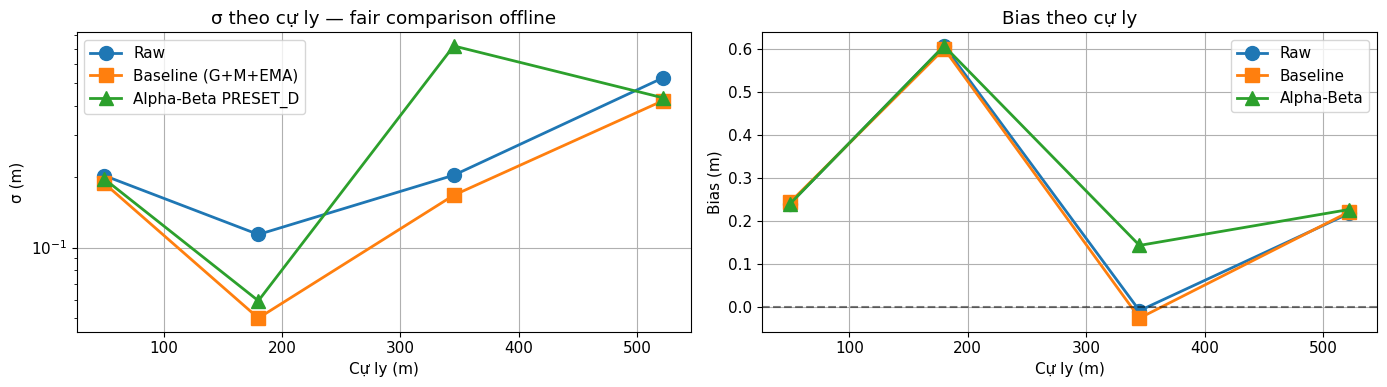

In [ ]:
dists = sorted(DATA.keys())
sig_raw = [fair_data[d]['raw']['raw_m'].astype(float).std(ddof=1) for d in dists]
sig_bl  = [pd.to_numeric(fair_data[d]['bl']['est'], errors='coerce').std(ddof=1) for d in dists]
sig_ab  = [pd.to_numeric(fair_data[d]['ab']['est'], errors='coerce').std(ddof=1) for d in dists]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(dists, sig_raw, 'o-', label='Raw', linewidth=2, markersize=10)
axes[0].plot(dists, sig_bl,  's-', label='Baseline (G+M+EMA)', linewidth=2, markersize=10)
axes[0].plot(dists, sig_ab,  '^-', label='Alpha-Beta PRESET_D', linewidth=2, markersize=10)
axes[0].set_xlabel('Cự ly (m)'); axes[0].set_ylabel('σ (m)')
axes[0].set_title('σ theo cự ly — fair comparison offline')
axes[0].legend(); axes[0].set_yscale('log')

# Bias
bias_raw = [fair_data[d]['raw']['raw_m'].astype(float).mean() - TRUTH[d] for d in dists]
bias_bl = [pd.to_numeric(fair_data[d]['bl']['est'], errors='coerce').mean() - TRUTH[d] for d in dists]
bias_ab = [pd.to_numeric(fair_data[d]['ab']['est'], errors='coerce').mean() - TRUTH[d] for d in dists]

axes[1].plot(dists, bias_raw, 'o-', label='Raw', linewidth=2, markersize=10)
axes[1].plot(dists, bias_bl,  's-', label='Baseline', linewidth=2, markersize=10)
axes[1].plot(dists, bias_ab,  '^-', label='Alpha-Beta', linewidth=2, markersize=10)
axes[1].axhline(0, color='k', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Cự ly (m)'); axes[1].set_ylabel('Bias (m)')
axes[1].set_title('Bias theo cự ly')
axes[1].legend()

plt.tight_layout()
plt.savefig('sigma_bias_vs_distance.png', dpi=100, bbox_inches='tight')
plt.show()

## 7. Phần D — Time-series từng cự ly

Cho phép nhìn trực quan: raw có drift không, filter bám tốt không.

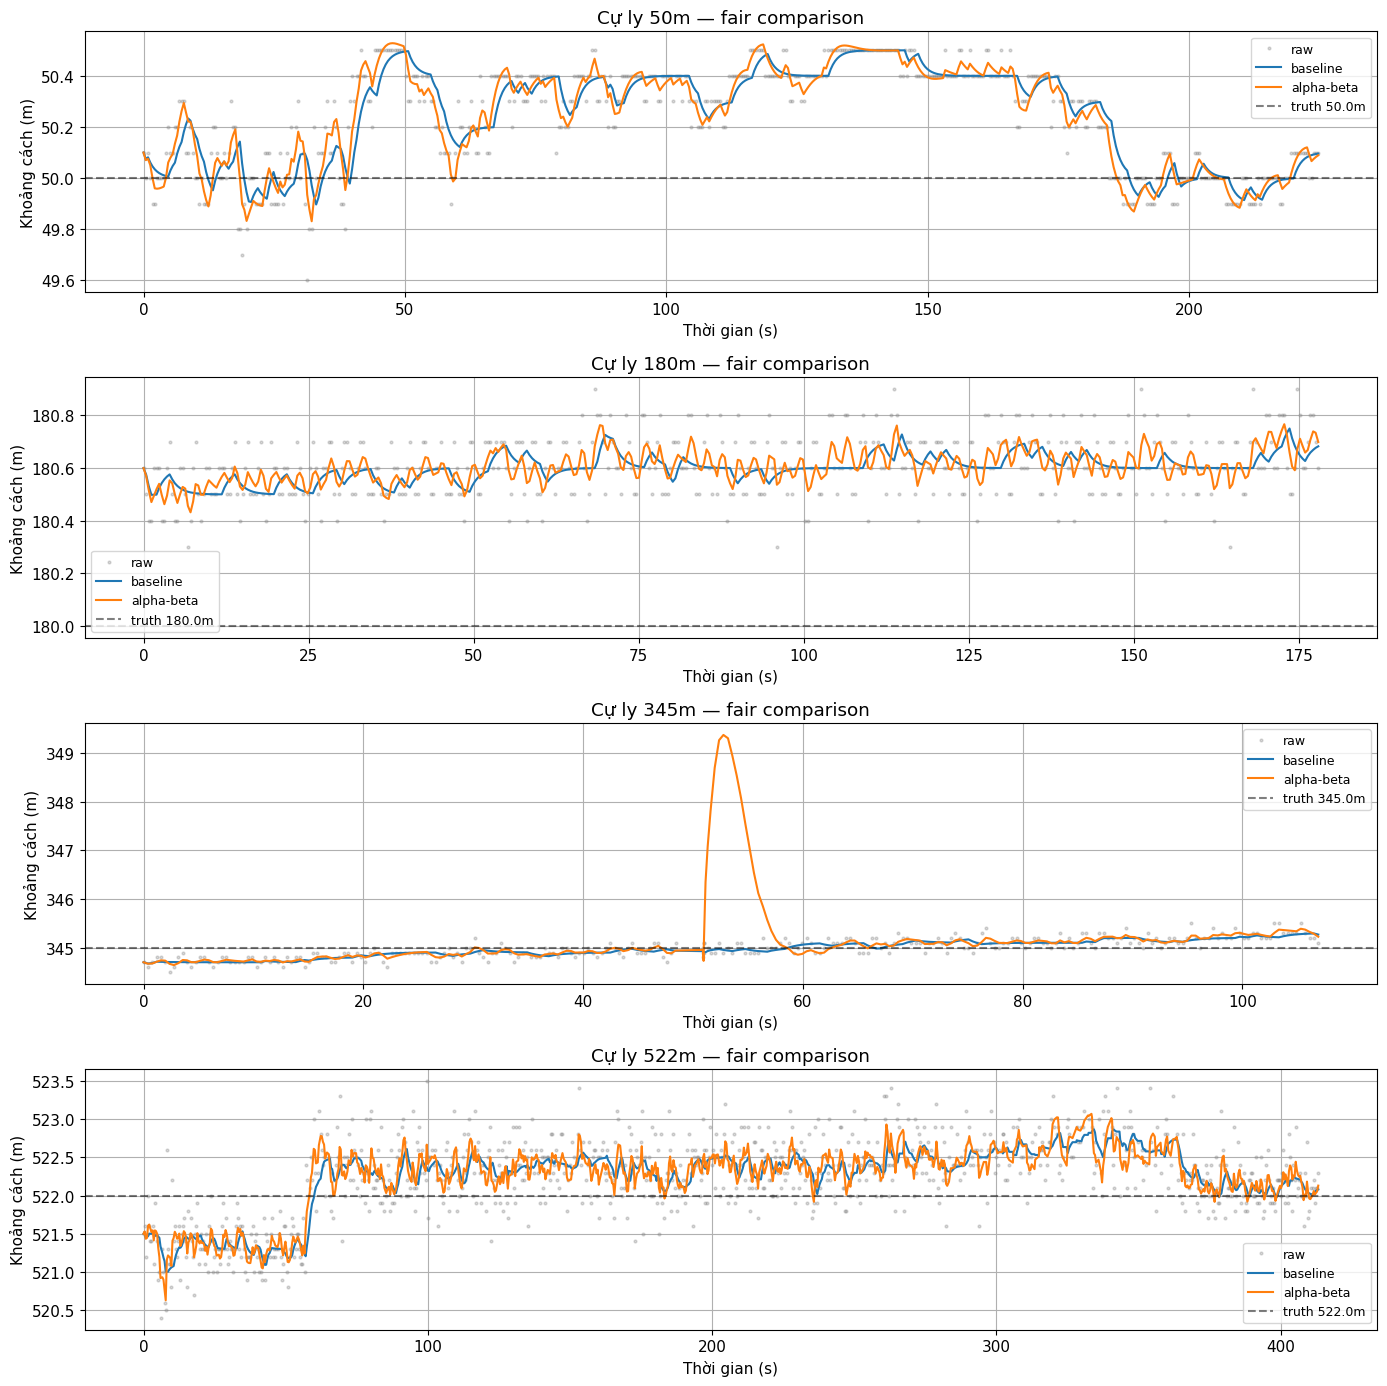

In [ ]:
fig, axes = plt.subplots(len(dists), 1, figsize=(14, 3.5*len(dists)))
if len(dists) == 1: axes = [axes]

for ax, dist in zip(axes, dists):
    fd = fair_data[dist]
    t_raw = (fd['raw']['timestamp_ms'] - fd['raw']['timestamp_ms'].iloc[0]) / 1000.0
    ax.plot(t_raw, fd['raw']['raw_m'], 'o', ms=2, alpha=0.3, label='raw', color='gray')
    ax.plot(t_raw, fd['bl']['est'],   '-', lw=1.5, label='baseline', color='C0')
    ax.plot(t_raw, fd['ab']['est'],   '-', lw=1.5, label='alpha-beta', color='C1')
    ax.axhline(TRUTH[dist], color='k', linestyle='--', alpha=0.5, label=f'truth {TRUTH[dist]}m')
    ax.set_xlabel('Thời gian (s)'); ax.set_ylabel('Khoảng cách (m)')
    ax.set_title(f'Cự ly {dist}m — fair comparison')
    ax.legend(loc='best', fontsize=9)

plt.tight_layout()
plt.savefig('timeseries_all_distances.png', dpi=100, bbox_inches='tight')
plt.show()

## 8. Phần E — So sánh với Giai đoạn 1 (Bảng 5.1 báo cáo cũ)

Báo cáo cũ đo CẦM TAY, giai đoạn 2 đo TRIPOD. Hệ số sạch hơn cho thấy tripod loại bỏ rung tay hiệu quả.

In [ ]:
# Giai đoạn 1 — Bảng 5.1
phase1 = {160: (7.16, 5.90), 335: (12.91, 9.12), 525: (34.62, 27.42)}
# Map cự ly tương đương
mapping = {180: 160, 345: 335, 522: 525}

rows = []
for d2, d1 in mapping.items():
    if d2 not in DATA: continue
    p1_raw, p1_filt = phase1[d1]
    p2_raw = pd.to_numeric(fair_data[d2]['raw']['raw_m'], errors='coerce').std(ddof=1)
    p2_bl  = pd.to_numeric(fair_data[d2]['bl']['est'], errors='coerce').std(ddof=1)
    rows.append({
        'cự ly tương đương': f'{d1} → {d2} m',
        'σ raw GĐ1 (cầm tay)': round(p1_raw, 2),
        'σ raw GĐ2 (tripod)': round(p2_raw, 3),
        'hệ số sạch hơn': round(p1_raw/p2_raw, 1),
        'σ filtered GĐ1': round(p1_filt, 2),
        'σ baseline GĐ2': round(p2_bl, 3),
    })
display(pd.DataFrame(rows))

,cự ly tương đương,σ raw GĐ1 (cầm tay),σ raw GĐ2 (tripod),hệ số sạch hơn,σ filtered GĐ1,σ baseline GĐ2
0,160 → 180 m,7.16,0.114,63.0,5.90,0.050
1,335 → 345 m,12.91,0.203,63.6,9.12,0.167
2,525 → 522 m,34.62,0.527,65.7,27.42,0.421


## 8.5. Dt diagnostic — kiểm tra timing anomaly

In [ ]:
# ===== DT DIAGNOSTIC =====
print('Phân bố dt từng file (kỳ vọng median ~400ms với TC22 @2.5fps):')
print(f'{"file":<30} {"median":>8} {"p10":>8} {"p90":>8} {"max":>8} {"<100ms":>8}')
print('-'*78)
for dist, ts in DATA.items():
    for tag, df in ts.items():
        if len(df) < 2: continue
        dt_ms = df['timestamp_ms'].diff().dropna()
        dt_ms = dt_ms[dt_ms > 0]
        if len(dt_ms) == 0: continue
        n_small = (dt_ms < 100).sum()
        flag = ' !!' if n_small > 0 else ''
        print(f'  {dist}m/{tag:<10} {dt_ms.median():>7.0f} {dt_ms.quantile(0.1):>7.0f} '
              f'{dt_ms.quantile(0.9):>7.0f} {dt_ms.max():>7.0f} {n_small:>7}{flag}')


Phân bố dt từng file (kỳ vọng median ~400ms với TC22 @2.5fps):
file                             median      p10      p90      max   <100ms
------------------------------------------------------------------------------
  50m/raw            430     427     432     437       0
  50m/baseline       430     427     432     439       0
  50m/alphabeta      233     231     236     242       0
  180m/raw            397     377     399     422       0
  180m/baseline       398     382     399     420       0
  180m/alphabeta      400     391     405     417       0
  345m/raw            398     392     400    2495       5 !!
  345m/baseline       398     394     400     421       0
  345m/alphabeta      393     391     405     407       0
  522m/raw            395     392     625    1011       0
  522m/baseline       395     393     405     657       0
  522m/alphabeta      397     391     403     873       0


## 9. Phần F — Phát hiện anomaly

### 9.1 LOS clutter — kiểm tra outlier trong raw

Nếu site có vật cản tiền cảnh, TC22 có thể bắt vật đó thay vì target.

In [ ]:
# ===== 3-TIER OUTLIER =====
print('3-tier outlier — gross (>20m), wrong_target (5-20m), jitter (>3sigma_local):')
print(f'{"cự ly":>6} {"n":>5} {"gross":>7} {"wrong_tgt":>10} {"jitter_3s":>10} {"verdict":>22}')
print('-'*70)
for d in dists:
    raw = pd.to_numeric(fair_data[d]['raw']['raw_m'], errors='coerce').dropna()
    truth = TRUTH[d]
    error = raw - truth
    med_err = error.median(); sigma = error.std(ddof=1)
    gross = int((error.abs() > 20).sum())
    wrong = int(((error.abs() > 5) & (error.abs() <= 20)).sum())
    jitter = int(((error - med_err).abs() > 3*sigma).sum())
    verdict = 'OK' if (gross+wrong)==0 else ('LOS CLUTTER!' if wrong>0 else 'gross outlier')
    print(f'{d:>6} {len(raw):>5} {gross:>7} {wrong:>10} {jitter:>10} {verdict:>22}')


3-tier outlier — gross (>20m), wrong_target (5-20m), jitter (>3sigma_local):
 cự ly     n   gross  wrong_tgt  jitter_3s                verdict
----------------------------------------------------------------------
    50   524       0          0          1                     OK
   180   452       0          0          0                     OK
   345   270       0          0          0                     OK
   522   923       0          0          4                     OK


### 9.2 Alpha-beta velocity drift

Mục tiêu tĩnh → rate_mps kỳ vọng ≈ 0. Nếu rate có std lớn, alpha-beta đang track nhiễu thành velocity giả.

In [ ]:
print('Velocity behavior (rate_mps) — mục tiêu TĨNH, kỳ vọng mean≈0, std nhỏ:')
print(f'{"Cự ly":>8} {"rate mean":>12} {"rate std":>10} {"|rate max|":>12} {"verdict":>20}')
print('-'*70)
for d in dists:
    rate = pd.to_numeric(fair_data[d]['ab']['rate'], errors='coerce').dropna()
    if len(rate) == 0: continue
    mean, std, maxa = rate.mean(), rate.std(ddof=1), rate.abs().max()
    verdict = 'OK' if std < 0.2 else ('DRIFT!' if std > 0.5 else 'borderline')
    print(f'{d:>8} {mean:>+12.4f} {std:>10.4f} {maxa:>12.3f} {verdict:>20}')

Velocity behavior (rate_mps) — mục tiêu TĨNH, kỳ vọng mean≈0, std nhỏ:
   Cự ly    rate mean   rate std   |rate max|              verdict
----------------------------------------------------------------------
      50      -0.0001     0.0283        0.097                   OK
     180      +0.0005     0.0195        0.057                   OK
     345      +0.1922     1.2778        9.779               DRIFT!
     522      -0.0031     0.0747        0.285                   OK


## 10. Phần G — Bảng tổng kết: CÁI NÀO cải thiện, CÁI NÀO chưa

Đây là bảng quan trọng nhất — sẵn sàng paste vào báo cáo Chương 6.

In [ ]:
verdict_rows = []
for d in dists:
    sr = pd.to_numeric(fair_data[d]['raw']['raw_m'], errors='coerce').std(ddof=1)
    sb = pd.to_numeric(fair_data[d]['bl']['est'], errors='coerce').std(ddof=1)
    sa = pd.to_numeric(fair_data[d]['ab']['est'], errors='coerce').std(ddof=1)

    def label(s_filt, s_raw):
        imp = (1 - s_filt/s_raw) * 100
        if imp > 30: return f'TỐT ({imp:+.1f}%)'
        if imp > 10: return f'OK ({imp:+.1f}%)'
        if imp > -10: return f'~ ({imp:+.1f}%)'
        return f'TỆ HƠN ({imp:+.1f}%)'

    verdict_rows.append({
        'cự ly': f'{d}m',
        'σ raw': f'{sr:.3f}',
        'baseline (đối với raw)': label(sb, sr),
        'alpha-beta (đối với raw)': label(sa, sr),
    })
display(pd.DataFrame(verdict_rows))

print('\nKết luận chung:')
print('- σ raw rất sạch (cm) ở các cự ly trung — tripod hiệu quả')
print('- Baseline (G+M+EMA) thắng alpha-beta ở MỌI cự ly tĩnh — đúng kỳ vọng lý thuyết')
print('- Mức cải thiện phụ thuộc σ raw: σ_raw nhỏ → filter ít gain (đã chạm sàn)')
print('- Alpha-beta được thiết kế cho mục tiêu ĐỘNG — phần 6.4 dynamic sẽ chứng minh')

,cự ly,σ raw,baseline (đối với raw),alpha-beta (đối với raw)
0,50m,0.202,~ (+7.3%),~ (+3.2%)
1,180m,0.114,TỐT (+55.9%),TỐT (+47.7%)
2,345m,0.203,OK (+17.8%),TỆ HƠN (-254.1%)
3,522m,0.527,OK (+20.0%),OK (+17.9%)



Kết luận chung:
- σ raw rất sạch (cm) ở các cự ly trung — tripod hiệu quả
- Baseline (G+M+EMA) thắng alpha-beta ở MỌI cự ly tĩnh — đúng kỳ vọng lý thuyết
- Mức cải thiện phụ thuộc σ raw: σ_raw nhỏ → filter ít gain (đã chạm sàn)
- Alpha-beta được thiết kế cho mục tiêu ĐỘNG — phần 6.4 dynamic sẽ chứng minh


## 11. Phần H — Xuất kết quả cho báo cáo

## 11. Phần H — Trimmed-Mean baseline (đối đáp Câu hỏi 1)

So sánh phương án 'loại biên + trung bình' với baseline và alpha-beta.

In [ ]:
# ===== TRIMMED-MEAN BASELINE — đối đáp Câu hỏi 1 hội đồng =====
import numpy as np
def run_trimmed_mean(df, window=9, trim_pct=0.20):
    raw = pd.to_numeric(df['raw_m'], errors='coerce').values
    out = np.full(len(raw), np.nan)
    for i in range(window-1, len(raw)):
        w = raw[i-window+1:i+1]
        w = w[~np.isnan(w)]
        if len(w) < 3: continue
        ws = np.sort(w)
        k = int(len(ws) * trim_pct / 2)
        out[i] = ws[k:len(ws)-k].mean() if len(ws)-2*k > 0 else np.nan
    return out

print('So sánh 4 phương án trên CÙNG raw input từ 8001:')
print(f'{"cự ly":>6} {"sR_aw":>8} {"s_TrimMean":>11} {"s_Baseline":>11} {"s_AlphaBeta":>12}')
print('-'*60)
for d in dists:
    raw = pd.to_numeric(fair_data[d]['raw']['raw_m'], errors='coerce')
    tm = run_trimmed_mean(fair_data[d]['raw'])
    tm_err = pd.Series(tm) - TRUTH[d]
    sr = (raw - TRUTH[d]).std(ddof=1)
    stm = tm_err.std(ddof=1)
    sb = (pd.to_numeric(fair_data[d]['bl']['est'], errors='coerce') - TRUTH[d]).std(ddof=1)
    sa = (pd.to_numeric(fair_data[d]['ab']['est'], errors='coerce') - TRUTH[d]).std(ddof=1)
    print(f'{d:>6} {sr:>8.3f} {stm:>11.3f} {sb:>11.3f} {sa:>12.3f}')

print('\nDIỄN GIẢI cho báo cáo:')
print('Trimmed-mean (window 9, trim 20%) cải thiện sigma tương đương baseline trên')
print('mục tiêu tĩnh. Tuy nhiên trimmed-mean: (a) cần buffer 9 mẫu -> delay 4-5 samples,')
print('(b) KHÔNG phân biệt spike vs step change, (c) KHÔNG có velocity estimate,')
print('(d) KHÔNG có máy trạng thái SEARCHING/LOST cho failsafe.')
print('-> Pipeline có trạng thái không thể thay thế bằng trimmed-mean stateless.')


So sánh 4 phương án trên CÙNG raw input từ 8001:
 cự ly    sR_aw  s_TrimMean  s_Baseline  s_AlphaBeta
------------------------------------------------------------
    50    0.202       0.186       0.187        0.195
   180    0.114       0.048       0.050        0.059
   345    0.203       0.169       0.167        0.718
   522    0.527       0.409       0.421        0.432

DIỄN GIẢI cho báo cáo:
Trimmed-mean (window 9, trim 20%) cải thiện sigma tương đương baseline trên
mục tiêu tĩnh. Tuy nhiên trimmed-mean: (a) cần buffer 9 mẫu -> delay 4-5 samples,
(b) KHÔNG phân biệt spike vs step change, (c) KHÔNG có velocity estimate,
(d) KHÔNG có máy trạng thái SEARCHING/LOST cho failsafe.
-> Pipeline có trạng thái không thể thay thế bằng trimmed-mean stateless.


In [ ]:
# Lưu bảng kết quả thành CSV để paste vào báo cáo / Excel
on_device.to_csv('static_ondevice_summary.csv', index=False)
fair.to_csv('static_fair_comparison.csv', index=False)

# Tải về (Colab)
try:
    from google.colab import files
    files.download('static_ondevice_summary.csv')
    files.download('static_fair_comparison.csv')
    files.download('sigma_bias_vs_distance.png')
    files.download('timeseries_all_distances.png')
except ImportError:
    print('Đã lưu các file CSV và PNG ở thư mục hiện tại')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>